In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries imported ✅")

Libraries imported ✅


In [2]:
# Load cleaned data
df = pd.read_csv('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/cleaned_retail.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create SQLite database
conn = sqlite3.connect('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/retail.db')

# Push dataframe into SQL table
df.to_sql('orders', conn, if_exists='replace', index=False)

print("✅ Database created!")
print("✅ Data loaded into SQL table: 'orders'")
print("Total rows in DB:", pd.read_sql("SELECT COUNT(*) FROM orders", conn).iloc[0,0])

✅ Database created!
✅ Data loaded into SQL table: 'orders'
Total rows in DB: 776577


In [3]:
query = """
SELECT *
FROM orders
LIMIT 5
"""

pd.read_sql(query, conn)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour,DayOfWeek,Quarter
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,7,Tuesday,4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday,4
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday,4
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,1,7,Tuesday,4
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,7,Tuesday,4


In [4]:
# Business Question: What are the overall business numbers?

query = """
SELECT 
    COUNT(DISTINCT Invoice)       AS Total_Orders,
    COUNT(DISTINCT [Customer ID]) AS Total_Customers,
    COUNT(DISTINCT StockCode)     AS Total_Products,
    ROUND(SUM(Revenue), 2)        AS Total_Revenue,
    ROUND(AVG(Revenue), 2)        AS Avg_Transaction_Value
FROM orders
"""

result = pd.read_sql(query, conn)
print("📊 Business Overview:")
result

📊 Business Overview:


,Total_Orders,Total_Customers,Total_Products,Total_Revenue,Avg_Transaction_Value
0,36594,5852,4619,17068567.97,21.98


In [5]:
# Business Question: How is revenue growing month over month?

query = """
SELECT 
    Year,
    Month,
    ROUND(SUM(Revenue), 2) AS Monthly_Revenue
FROM orders
GROUP BY Year, Month
ORDER BY Year, Month
"""

monthly = pd.read_sql(query, conn)

# Calculate Month over Month growth
monthly['Prev_Revenue'] = monthly['Monthly_Revenue'].shift(1)
monthly['MoM_Growth_%'] = ((monthly['Monthly_Revenue'] - monthly['Prev_Revenue']) 
                            / monthly['Prev_Revenue'] * 100).round(2)

monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

print("📈 Monthly Revenue with Growth %:")
print(monthly[['Period','Monthly_Revenue','MoM_Growth_%']].to_string(index=False))

📈 Monthly Revenue with Growth %:
 Period  Monthly_Revenue  MoM_Growth_%
2009-12        677916.07           NaN
2010-01        533712.98        -21.27
2010-02        497937.57         -6.70
2010-03        665973.67         33.75
2010-04        585127.43        -12.14
2010-05        592734.13          1.30
2010-06        628809.40          6.09
2010-07        581487.96         -7.53
2010-08        594561.17          2.25
2010-09        805544.81         35.49
2010-10       1011556.75         25.57
2010-11       1155978.39         14.28
2010-12        565199.56        -51.11
2011-01        562682.91         -0.45
2011-02        442293.59        -21.40
2011-03        583143.85         31.85
2011-04        454440.88        -22.07
2011-05        659242.49         45.07
2011-06        653264.92         -0.91
2011-07        591603.79         -9.44
2011-08        635514.38          7.42
2011-09        938752.63         47.72
2011-10       1002326.56          6.77
2011-11       1136534.00       

In [6]:
# Business Question: Who are our highest value customers?

query = """
SELECT 
    [Customer ID],
    COUNT(DISTINCT Invoice)  AS Total_Orders,
    ROUND(SUM(Revenue), 2)   AS Total_Revenue,
    ROUND(AVG(Revenue), 2)   AS Avg_Order_Value,
    COUNT(DISTINCT StockCode) AS Unique_Products_Bought
FROM orders
GROUP BY [Customer ID]
ORDER BY Total_Revenue DESC
LIMIT 10
"""

top_customers = pd.read_sql(query, conn)
print("👑 Top 10 Customers:")
top_customers

👑 Top 10 Customers:


,Customer ID,Total_Orders,Total_Revenue,Avg_Order_Value,Unique_Products_Bought
0,18102,145,580987.04,558.64,382
1,14646,145,526751.52,137.93,960
2,14156,144,303069.88,75.88,1443
3,14911,373,272252.79,24.96,2546
4,17450,51,244784.25,582.82,144
5,13694,143,195640.69,128.80,896
6,17511,60,172132.87,92.15,657
7,16446,2,168472.50,56157.50,3
8,16684,55,147142.77,204.93,184
9,12415,24,144033.37,156.22,496


In [7]:
# Business Question: Which countries drive most revenue?

query = """
SELECT 
    Country,
    COUNT(DISTINCT Invoice)       AS Total_Orders,
    COUNT(DISTINCT [Customer ID]) AS Total_Customers,
    ROUND(SUM(Revenue), 2)        AS Total_Revenue,
    ROUND(SUM(Revenue) * 100.0 / 
        (SELECT SUM(Revenue) FROM orders), 2) AS Revenue_Pct
FROM orders
GROUP BY Country
ORDER BY Total_Revenue DESC
LIMIT 10
"""

country_revenue = pd.read_sql(query, conn)
print("🌍 Revenue by Country:")
country_revenue

🌍 Revenue by Country:


,Country,Total_Orders,Total_Customers,Total_Revenue,Revenue_Pct
0,United Kingdom,33361,5334,14288758.75,83.71
1,EIRE,528,3,586626.08,3.44
2,Netherlands,216,22,549773.41,3.22
3,Germany,753,107,383289.00,2.25
4,France,590,93,309403.16,1.81
5,Australia,89,15,167800.01,0.98
6,Spain,144,38,97766.75,0.57
7,Switzerland,82,22,93400.94,0.55
8,Sweden,98,19,86045.14,0.50
9,Denmark,42,12,67422.69,0.40


In [8]:
# Business Question: Which products generate most money?

query = """
SELECT 
    StockCode,
    Description,
    SUM(Quantity)          AS Total_Qty_Sold,
    ROUND(SUM(Revenue), 2) AS Total_Revenue,
    ROUND(AVG(Price), 2)   AS Avg_Price
FROM orders
GROUP BY StockCode, Description
ORDER BY Total_Revenue DESC
LIMIT 10
"""

top_products = pd.read_sql(query, conn)
print("🏆 Top 10 Products:")
top_products

🏆 Top 10 Products:


,StockCode,Description,Total_Qty_Sold,Total_Revenue,Avg_Price
0,22423,REGENCY CAKESTAND 3 TIER,24124,277656.25,12.46
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757,247048.01,2.87
2,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,2.08
3,85099B,JUMBO BAG RED RETROSPOT,74224,134307.44,1.97
4,84879,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86,1.68
5,47566,PARTY BUNTING,23460,103283.38,4.77
6,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,1.22
7,22086,PAPER CHAIN KIT 50'S CHRISTMAS,28380,76598.18,2.92
8,79321,CHILLI LIGHTS,14843,69084.30,5.15
9,85099F,JUMBO BAG STRAWBERRY,35842,64127.77,1.96


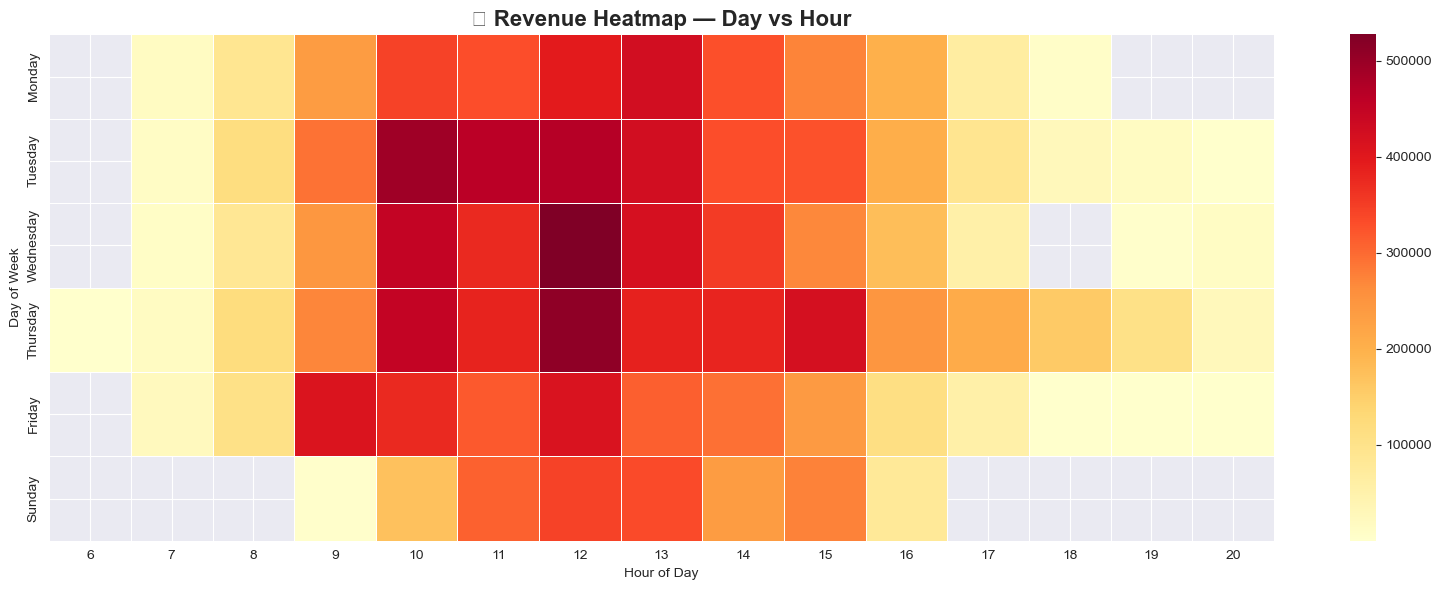

In [10]:
# Business Question: When exactly is the business busiest?

query = """
SELECT 
    DayOfWeek,
    Hour,
    ROUND(SUM(Revenue), 2) AS Revenue
FROM orders
GROUP BY DayOfWeek, Hour
ORDER BY DayOfWeek, Hour
"""

heatmap_data = pd.read_sql(query, conn)

# Pivot for heatmap
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Sunday']
pivot = heatmap_data.pivot(index='DayOfWeek', columns='Hour', values='Revenue')
pivot = pivot.reindex(day_order)

plt.figure(figsize=(16, 6))
sns.heatmap(pivot, cmap='YlOrRd', fmt='.0f', linewidths=0.5)
plt.title('🔥 Revenue Heatmap — Day vs Hour', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/09_heatmap.png', dpi=150)
plt.show()

In [11]:
# Business Question: Which quarter performs best?

query = """
SELECT 
    Year,
    Quarter,
    ROUND(SUM(Revenue), 2)        AS Quarterly_Revenue,
    COUNT(DISTINCT Invoice)        AS Total_Orders,
    COUNT(DISTINCT [Customer ID])  AS Active_Customers
FROM orders
GROUP BY Year, Quarter
ORDER BY Year, Quarter
"""

quarterly = pd.read_sql(query, conn)
quarterly['Period'] = 'Q' + quarterly['Quarter'].astype(str) + ' ' + quarterly['Year'].astype(str)
print("📆 Quarterly Performance:")
quarterly[['Period','Quarterly_Revenue','Total_Orders','Active_Customers']]

📆 Quarterly Performance:


,Period,Quarterly_Revenue,Total_Orders,Active_Customers
0,Q4 2009,677916.07,1497,951
1,Q1 2010,1697624.22,3561,1783
2,Q2 2010,1806670.96,4159,2040
3,Q3 2010,1981593.94,4297,2051
4,Q4 2010,2732734.70,6072,2665
5,Q1 2011,1588120.35,3287,1774
6,Q2 2011,1766948.29,4073,1988
7,Q3 2011,2165870.80,4327,2155
8,Q4 2011,2651088.64,5321,2559


📊 Purchase Frequency Distribution:
count    5852.000000
mean        6.253247
std        12.749286
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       373.000000
Name: Purchase_Count, dtype: float64


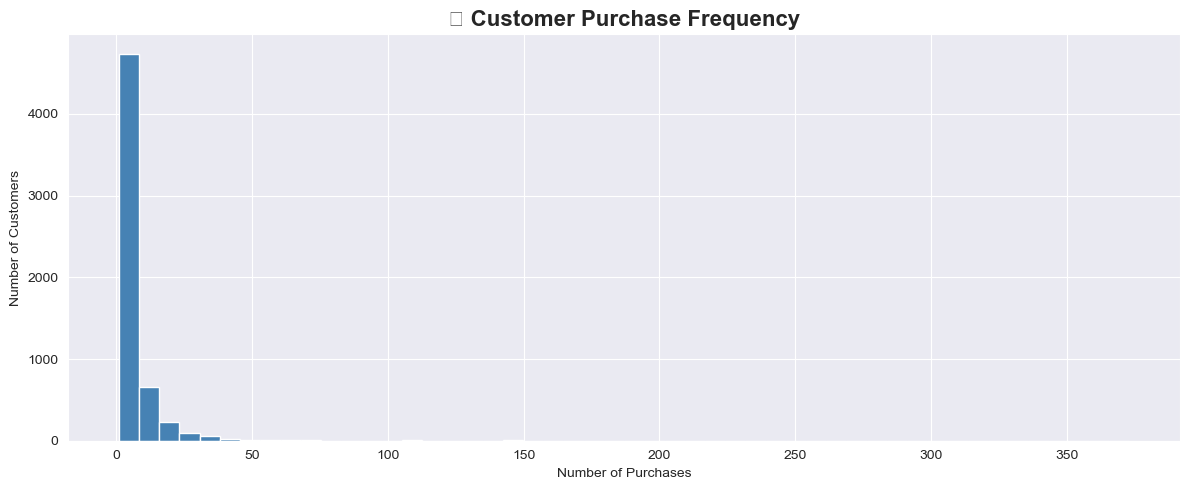


📌 Most customers buy only: 3 times
📌 Most loyal customer bought: 373 times


In [13]:
# Business Question: How often do customers buy?

query = """
SELECT 
    [Customer ID],
    COUNT(DISTINCT Invoice) AS Purchase_Count
FROM orders
GROUP BY [Customer ID]
"""

freq = pd.read_sql(query, conn)

print("📊 Purchase Frequency Distribution:")
print(freq['Purchase_Count'].describe())

plt.figure(figsize=(12, 5))
plt.hist(freq['Purchase_Count'], bins=50, color='steelblue', edgecolor='white')
plt.title('🛒 Customer Purchase Frequency', fontsize=16, fontweight='bold')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/10_purchase_freq.png', dpi=150)
plt.show()

print(f"\n📌 Most customers buy only: {freq['Purchase_Count'].median():.0f} times")
print(f"📌 Most loyal customer bought: {freq['Purchase_Count'].max()} times")

In [14]:
# Business Question: Which country has highest average order value?

query = """
SELECT 
    Country,
    ROUND(SUM(Revenue) / COUNT(DISTINCT Invoice), 2) AS Avg_Order_Value,
    COUNT(DISTINCT Invoice) AS Total_Orders
FROM orders
GROUP BY Country
HAVING Total_Orders > 50
ORDER BY Avg_Order_Value DESC
LIMIT 10
"""

aov = pd.read_sql(query, conn)
print("💰 Average Order Value by Country:")
aov

💰 Average Order Value by Country:


,Country,Avg_Order_Value,Total_Orders
0,Netherlands,2545.25,216
1,Australia,1885.39,89
2,Switzerland,1139.04,82
3,EIRE,1111.03,528
4,Sweden,878.01,98
5,Channel Islands,815.38,54
6,Spain,678.94,144
7,Portugal,561.56,83
8,France,524.41,590
9,Germany,509.02,753


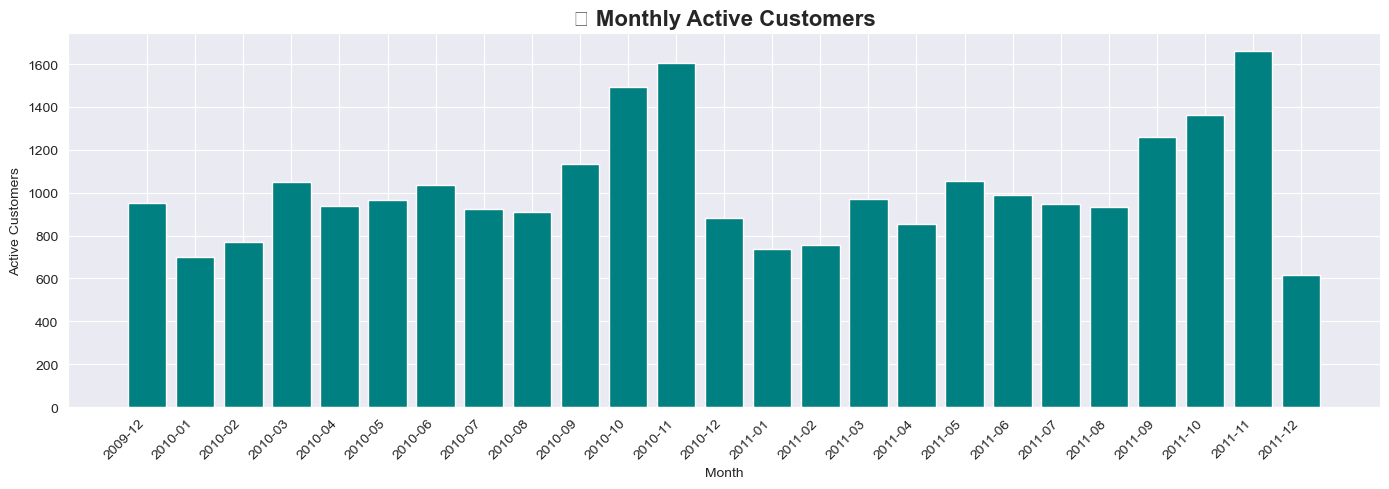

In [15]:
# Business Question: How many new customers join each month?

query = """
SELECT 
    Year,
    Month,
    COUNT(DISTINCT [Customer ID]) AS Active_Customers
FROM orders
GROUP BY Year, Month
ORDER BY Year, Month
"""

monthly_customers = pd.read_sql(query, conn)
monthly_customers['Period'] = (monthly_customers['Year'].astype(str) + '-' + 
                                monthly_customers['Month'].astype(str).str.zfill(2))

plt.figure(figsize=(14, 5))
plt.bar(monthly_customers['Period'], monthly_customers['Active_Customers'], color='teal')
plt.xticks(rotation=45, ha='right')
plt.title('👥 Monthly Active Customers', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Active Customers')
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/11_monthly_customers.png', dpi=150)
plt.show()

In [16]:
print("=" * 55)
print("🗄️ SQL ANALYSIS COMPLETE — KEY FINDINGS")
print("=" * 55)

summary = pd.read_sql("""
    SELECT 
        ROUND(SUM(Revenue), 2)          AS Total_Revenue,
        COUNT(DISTINCT Invoice)          AS Total_Orders,
        COUNT(DISTINCT [Customer ID])    AS Total_Customers,
        COUNT(DISTINCT Country)          AS Total_Countries,
        ROUND(AVG(Revenue), 2)           AS Avg_Transaction
    FROM orders
""", conn)

print(summary.to_string(index=False))
print("\n10 SQL queries executed successfully ✅")
print("4 charts generated ✅")
print("=" * 55)

conn.close()
print("\n🔒 Database connection closed ✅")

🗄️ SQL ANALYSIS COMPLETE — KEY FINDINGS
 Total_Revenue  Total_Orders  Total_Customers  Total_Countries  Avg_Transaction
   17068567.97         36594             5852               41            21.98

10 SQL queries executed successfully ✅
4 charts generated ✅

🔒 Database connection closed ✅
